In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Solid_Waste_Generation___Recycling.csv")

In [3]:
data

,Year,Agricultural Organics,Aluminum Cans,Anti-freeze,Appliances/White Goods,"Ash, Sand & Dust used in Asphalt Production",Asphalt/Concrete,Batteries - Auto Lead Acid,Cardboard,Carpet & Pad,...,Waste Types Excluded from Recovery Rate,All Other Waste Types,Total Solid Waste Disposed (recoverable portion),All Solid Waste Disposal,Solid Waste Generated (recoverable portion),Overall Waste Generated (recoverable and non-recoverable),Material Recovery Rate,Population,Solid Waste Generated (pounds/person/day),Material Reovered (pounds/person/day)
0,2000,0,17944,2475,35427,10000,893218,10757,495470,97,...,549239.00,2515427.00,6.577102e+06,7126341,10463584,11012823,37.14,5894100,10.238075,3.613069
1,2001,0,12540,4157,39180,12333,1116871,16297,491230,820,...,1192376.00,2838771.00,6.257801e+06,7450177,10524608,11716984,40.54,5974900,10.745394,3.912997
2,2002,0,12718,4506,43833,290,1451959,12158,417534,148,...,1343941.00,2724337.00,6.084275e+06,7428216,10998676,12342617,44.68,6041700,11.193998,4.457061
3,2003,0,17608,4722,53353,10576,1600288,18780,430750,258,...,1350013.00,2666863.00,6.122052e+06,7472065,11353874,12703887,46.08,6098300,11.414713,4.700903
4,2004,0,16010,8050,56920,40409,2002171,25518,535662,304,...,2557428.00,4153915.00,6.526087e+06,9083515,12760061,15317489,48.86,6167800,13.608004,5.538241
5,2005,0,15441,8767,47302,14588,1783418,28903,565698,186,...,2736151.00,5355491.00,7.696424e+06,10432575,14758169,17494320,47.85,6256400,15.321797,6.184786
6,2006,0,14951,7507,49796,4008,2295278,25414,570802,897,...,1689840.00,4164837.00,7.760714e+06,9450554,15442903,17132743,49.75,6375600,14.724582,6.602388
7,2007,0,14005,7055,44667,2521,2089972,25734,555757,1193,...,1810580.00,4557764.00,8.082291e+06,9892871,15372234,17182814,47.42,6488000,14.511776,6.156734
8,2008,31800,12842,6586,43401,0,1510051,25219,569688,3297,...,1634267.82,4154879.40,7.516909e+06,9151177,14309506,15943774,47.47,6587600,13.261756,5.649965
9,2009,45431,21098,5194,39777,344,2186429,21493,491266,3317,...,1550645.32,3039032.92,6.126660e+06,7677305,13564327,15114972,54.83,6668200,12.420408,6.111746


In [4]:
data.shape

(15, 80)

# Detecting Outlier

## 1. Sort Values

In [6]:
df = data.sort_values('Aluminum Cans')

In [8]:
df['Aluminum Cans'].head()

1     12540
2     12718
8     12842
11    13115
12    13635
Name: Aluminum Cans, dtype: int64

In [9]:
df['Aluminum Cans'].tail()

4     16010
13    16679
3     17608
0     17944
9     21098
Name: Aluminum Cans, dtype: int64

In [10]:
21098 - 12540

8558

### so last Vale is outlier

## 2. Drawing Graphs/ Plots

In [12]:
# boxplot
# histogram
# scatter plot

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import warnings
warnings.filterwarnings("ignore")

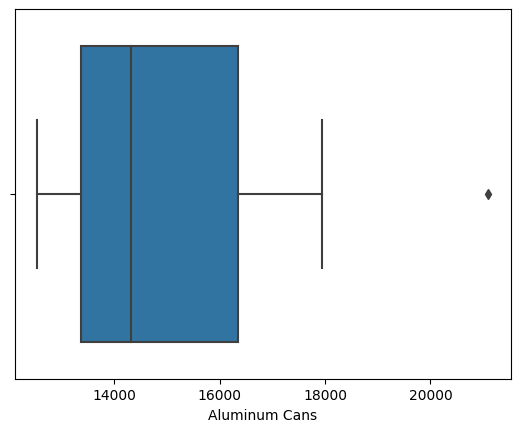

In [14]:
sns.boxplot(data = data , x = 'Aluminum Cans')
plt.show()

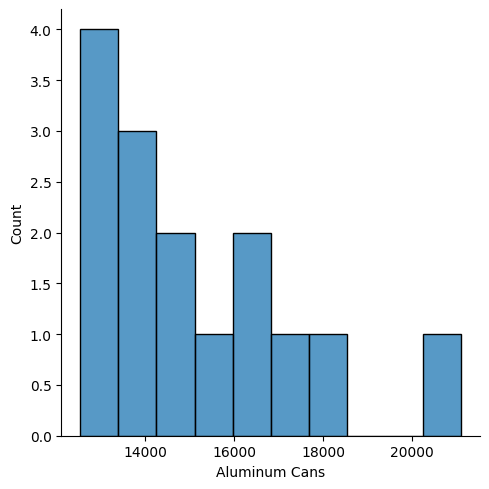

In [15]:
sns.displot(data = data , x ='Aluminum Cans' , bins = 10)
plt.show()

# IQR ( Inter Quartile Range)

In [16]:
q3 = data['Aluminum Cans'].quantile(0.75)
q1 = data['Aluminum Cans'].quantile(0.25)

In [17]:
iqr = q3 - q1

In [18]:
iqr

2969.5

In [19]:
ul = q3  + (1.5 * iqr)
ll = q1 - (1.5 * iqr)

In [20]:
ul

20798.75

In [21]:
ll

8920.75

# how to handel outlier

In [22]:
# if big dataset the we can remove the outlier
upper = np.where(data['Aluminum Cans'] >= ul)
lower = np.where(data['Aluminum Cans'] <= ll)

In [ ]:
data.drop(upper[0] , inplace = True)
data.drop(lower[0] , inplace = True)

In [23]:
# but wheen data is not big so replace outlier through mean  , median , or others values in columns
arr = data['Aluminum Cans'].values
arr

array([17944, 12540, 12718, 17608, 16010, 15441, 14951, 14005, 12842,
       21098, 13655, 13115, 13635, 16679, 14309], dtype=int64)

In [24]:
true_index = (ll < arr) & (arr < ul)
true_index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True])

In [26]:
mid = np.median(data['Aluminum Cans'][true_index])
mid

14157.0

In [27]:
# now replace value
false_index = ~true_index # ~ is bool operator of invers
data['Aluminum Cans'].values[false_index] = mid
data

,Year,Agricultural Organics,Aluminum Cans,Anti-freeze,Appliances/White Goods,"Ash, Sand & Dust used in Asphalt Production",Asphalt/Concrete,Batteries - Auto Lead Acid,Cardboard,Carpet & Pad,...,Waste Types Excluded from Recovery Rate,All Other Waste Types,Total Solid Waste Disposed (recoverable portion),All Solid Waste Disposal,Solid Waste Generated (recoverable portion),Overall Waste Generated (recoverable and non-recoverable),Material Recovery Rate,Population,Solid Waste Generated (pounds/person/day),Material Reovered (pounds/person/day)
0,2000,0,17944,2475,35427,10000,893218,10757,495470,97,...,549239.00,2515427.00,6.577102e+06,7126341,10463584,11012823,37.14,5894100,10.238075,3.613069
1,2001,0,12540,4157,39180,12333,1116871,16297,491230,820,...,1192376.00,2838771.00,6.257801e+06,7450177,10524608,11716984,40.54,5974900,10.745394,3.912997
2,2002,0,12718,4506,43833,290,1451959,12158,417534,148,...,1343941.00,2724337.00,6.084275e+06,7428216,10998676,12342617,44.68,6041700,11.193998,4.457061
3,2003,0,17608,4722,53353,10576,1600288,18780,430750,258,...,1350013.00,2666863.00,6.122052e+06,7472065,11353874,12703887,46.08,6098300,11.414713,4.700903
4,2004,0,16010,8050,56920,40409,2002171,25518,535662,304,...,2557428.00,4153915.00,6.526087e+06,9083515,12760061,15317489,48.86,6167800,13.608004,5.538241
5,2005,0,15441,8767,47302,14588,1783418,28903,565698,186,...,2736151.00,5355491.00,7.696424e+06,10432575,14758169,17494320,47.85,6256400,15.321797,6.184786
6,2006,0,14951,7507,49796,4008,2295278,25414,570802,897,...,1689840.00,4164837.00,7.760714e+06,9450554,15442903,17132743,49.75,6375600,14.724582,6.602388
7,2007,0,14005,7055,44667,2521,2089972,25734,555757,1193,...,1810580.00,4557764.00,8.082291e+06,9892871,15372234,17182814,47.42,6488000,14.511776,6.156734
8,2008,31800,12842,6586,43401,0,1510051,25219,569688,3297,...,1634267.82,4154879.40,7.516909e+06,9151177,14309506,15943774,47.47,6587600,13.261756,5.649965
9,2009,45431,14157,5194,39777,344,2186429,21493,491266,3317,...,1550645.32,3039032.92,6.126660e+06,7677305,13564327,15114972,54.83,6668200,12.420408,6.111746


# remove another outlier

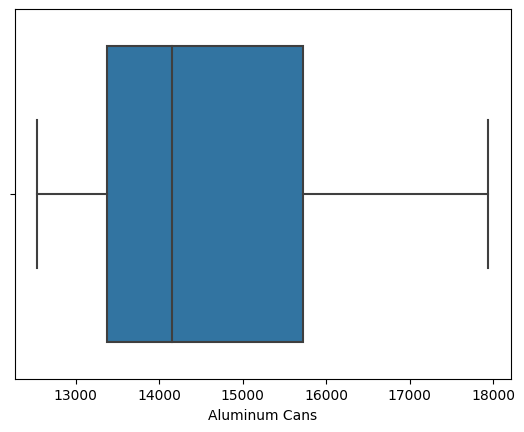

In [30]:
sns.boxplot(data = data, x='Aluminum Cans')
plt.show()